# Grid-to-Catchment Weighting: Downscaled Temperature + Precipitation

Proof-of-concept for mapping HiRO-ACE's downscaled 2m temperature (lapse-rate
DEM correction, `processing/temp_downscaling/`) and downscaled precipitation
(HiRO, `PRATEsfc`) onto the Japan hydro model's catchment polygons, using
area-weighted grid-to-catchment interpolation.

Reuses the weighting logic from `hydro/compute_interpolation_weights.ipynb`
(confirmed identical to its `hydro/modified_code/` duplicate -- the two only
differ in a hardcoded path/test-file config cell, not in any function), moved
into `catchment_weighting_lib.py` and generalised:

- works with a grid in *either* lat/lon direction (the original assumed
  ERA5's decreasing-latitude grid; HiRO's grid increases in both lat and lon)
- resolves the ambiguity the original notebook's last cell flagged
  ("you may need to ... rename some columns") by treating each grid point as
  a cell *center* (midpoint edges) instead of using consecutive points as ad
  hoc cell edges -- see `docs/catchment_weighting.md` for the full rationale.
- adds the actual "apply weights to a gridded field" step (an area-weighted
  **mean**), which the original notebook stopped short of.
- includes a `to_diffhydro_weight_format` compatibility layer, checked
  directly against [TristHas/DiffHydro](https://github.com/TristHas/DiffHydro)'s
  source -- see the "Aside" section below for why that's a *different*
  weighting (area-weighted **sum**) used for a later pipeline stage
  (runoff → catchment inflow volume), not this notebook's forcing-averaging.

Both HiRO outputs already sit on the same 704x736 grid (temperature
downscaling used the precip output as its `--target-grid`), so one set of
weights serves both variables.

Once this proves out, `run_catchment_weighting.py` is the zarr-native CLI
version of the same steps -- see its docstring for example invocations.

## Setup

In [1]:
import sys
sys.path.insert(0, ".")  # this notebook lives in scripts/, alongside the lib

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt

import catchment_weighting_lib as cwl

## Configuration

Paths below are local/machine-specific (same spirit as the original
notebook's hardcoded ERA5 path) -- adjust for your machine.

In [2]:
BASINS_PATH = "/Users/valentin/Desktop/UNRISK/Projects/hydrological_model/Japan_model/data/basins.pkl"

# HiRO-ACE downscaled outputs -- both on the same 3km-ish grid (see markdown above)
TEMP_ZARR    = "/Users/valentin/Desktop/UNRISK/Projects/Climate_models/HiroACE/local/temperature_downscaling/hiro/TMP2m_corrected.zarr"
PRECIP_ZARR  = "/Users/valentin/Desktop/UNRISK/Projects/Climate_models/HiroACE/local/output/hiro_downscaled/Japan_two_steps_20230101_0000_0600.zarr"

TEMP_LAT_VAR, TEMP_LON_VAR     = "lat", "lon"
PRECIP_LAT_VAR, PRECIP_LON_VAR = "latitude", "longitude"

DATA_DIR = "../data"  # gitignored (repo-wide *.pkl / *.zarr / data/ rules) -- weight cache + demo outputs land here
WEIGHTS_CACHE = f"{DATA_DIR}/hiro_grid_weights.pkl"

N_JOBS = -1

In [3]:
from pathlib import Path
Path(DATA_DIR).mkdir(parents=True, exist_ok=True)

## Load catchments

`basins.pkl` is a GeoSeries of catchment polygons indexed by catchment ID
(no CRS stored on disk in this case -- `load_basins` assumes EPSG:4326,
same as `hydro/exp_helpers.py` does when it loads the equivalent files).

In [4]:
basins = cwl.load_basins(BASINS_PATH)
print(f"Loaded {len(basins)} catchment polygons")
print(f"CRS    : {basins.crs}")
print(f"Bounds : {basins.total_bounds}  (minx, miny, maxx, maxy)")
basins.head(3)

Loaded 8893 catchment polygons
CRS    : epsg:4326
Bounds : [129.62222222  30.29       146.235       45.45055556]  (minx, miny, maxx, maxy)


2600468634    POLYGON ((134.99889 34.82667, 134.99861 34.826...
2336227590    MULTIPOLYGON (((140.09472 36.02361, 140.09472 ...
2336228014    POLYGON ((140.15 36.06056, 140.15 36.06028, 14...
dtype: geometry

## Load the target grid

Read HiRO's grid off the temperature store and sanity-check the precip
store sits on the exact same grid (point-for-point), since we'll reuse one
weight set for both.

In [5]:
grid_lat, grid_lon = cwl.load_grid(TEMP_ZARR, TEMP_LAT_VAR, TEMP_LON_VAR)
precip_lat, precip_lon = cwl.load_grid(PRECIP_ZARR, PRECIP_LAT_VAR, PRECIP_LON_VAR)

same_grid = grid_lat.shape == precip_lat.shape and np.allclose(grid_lat, precip_lat) \
    and grid_lon.shape == precip_lon.shape and np.allclose(grid_lon, precip_lon)
print(f"Temp grid  : {len(grid_lat)} x {len(grid_lon)} points, "
      f"lat [{grid_lat.min():.3f}, {grid_lat.max():.3f}], lon [{grid_lon.min():.3f}, {grid_lon.max():.3f}]")
print(f"Precip grid matches temp grid exactly: {same_grid}")
assert same_grid, "temp and precip grids differ -- weights computed for one won't apply to the other" 

Temp grid  : 704 x 736 points, lat [23.949, 45.857], lon [123.016, 145.984]
Precip grid matches temp grid exactly: True


## Compute (or load cached) catchment weights

Expensive step (polygon/cell intersection for ~8,900 catchments) -- cached
to `WEIGHTS_CACHE` so subsequent runs (or the precipitation variable below,
which shares this grid) skip straight past it.

In [6]:
weights_path = Path(WEIGHTS_CACHE)
if weights_path.exists():
    print(f"Loading cached weights from {weights_path} ...")
    weights_df = cwl.load_weights(weights_path)
else:
    print(f"Computing weights for {len(basins)} catchments x {len(grid_lat)}x{len(grid_lon)} grid ...")
    weights_df = cwl.compute_weights(basins, grid_lat, grid_lon, n_jobs=N_JOBS)
    cwl.save_weights(weights_df, weights_path)
    print(f"Cached -> {weights_path}")

print(f"\n{weights_df.shape[0]} (polygon, cell) weight rows for {weights_df['polygon_index'].nunique()} catchments")
weights_df.head()

Loading cached weights from ../data/hiro_grid_weights.pkl ...

95673 (polygon, cell) weight rows for 8893 catchments


,polygon_index,i,j,weight,norm_weight
0,2600468634,348,383,6.610513e-07,0.000158
1,2600468634,348,384,5.125548e-05,0.012241
2,2600468634,348,385,2.184188e-05,0.005216
3,2600468634,349,383,6.051910e-06,0.001445
4,2600468634,349,384,9.214628e-04,0.220063


## Validate

Normalised weights must sum to 1 for every catchment; also flags any
catchments poking outside the grid's bounding box (edge-of-domain effects,
e.g. small offshore islands near HiRO's domain boundary).

In [7]:
norm_sums = cwl.validate_weights(weights_df, basins=basins, grid_lat=grid_lat, grid_lon=grid_lon)

Max deviation from 1.0 : 2.22e-16
All 8893 polygons validated ✓

Grid cells per basin -- min: 1  median: 11  max: 28
Basins covered by a single cell (nearest-neighbour fallback): 231

⚠ 4 catchment(s) extend outside the grid's bounding box (clipped/nearest-cell coverage near the domain edge): [404650196, 402520316, 394064520, 393999971]


## Visual sanity check

Zoom into a handful of catchments and overlay the grid cells that
contribute weight to them, colored by `norm_weight` -- this is the direct
visual proof that the area-weighting is doing something sensible before
trusting it on real data.

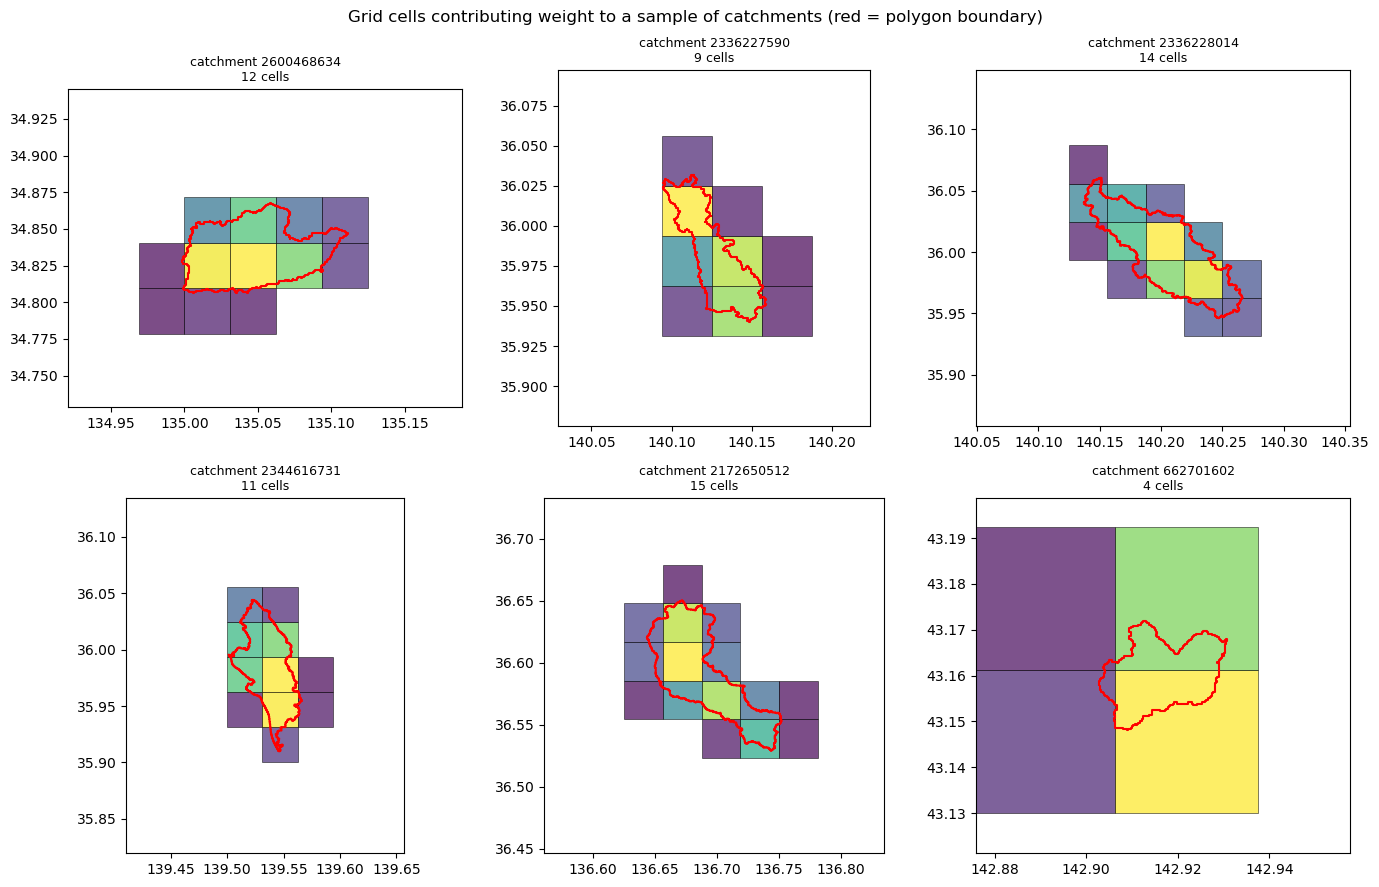

In [8]:
sample_ids = basins.index[:6]
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

lat_edges = cwl.cell_edges(grid_lat)
lon_edges = cwl.cell_edges(grid_lon)

for ax, pid in zip(axes.ravel(), sample_ids):
    rows = weights_df[weights_df["polygon_index"] == pid]
    poly = basins.loc[pid]
    minx, miny, maxx, maxy = poly.bounds
    pad = max(maxx - minx, maxy - miny) * 0.6 + 0.01

    for _, r in rows.iterrows():
        i, j = int(r["i"]), int(r["j"])
        cell = plt.Rectangle((min(lon_edges[j], lon_edges[j+1]), min(lat_edges[i], lat_edges[i+1])),
                              abs(lon_edges[j+1] - lon_edges[j]),
                              abs(lat_edges[i+1] - lat_edges[i]),
                              facecolor=plt.cm.viridis(r["norm_weight"] / rows["norm_weight"].max()),
                              edgecolor="k", linewidth=0.5, alpha=0.7)
        ax.add_patch(cell)

    gpd.GeoSeries([poly]).boundary.plot(ax=ax, color="red", linewidth=1.5)
    ax.set_xlim(minx - pad, maxx + pad)
    ax.set_ylim(miny - pad, maxy + pad)
    ax.set_title(f"catchment {pid}\n{len(rows)} cells", fontsize=9)

fig.suptitle("Grid cells contributing weight to a sample of catchments (red = polygon boundary)")
fig.tight_layout()
plt.show()

## Apply weights to temperature

`TMP2m_corrected.zarr` is small (40 timesteps, ~166 MB) -- load the full
series and area-weight it onto catchments in one shot.

In [9]:
temp_ds = xr.open_zarr(TEMP_ZARR)
temp_da = temp_ds["TMP2m"].load()
print(temp_da.dims, temp_da.shape)

temp_catchments = cwl.apply_catchment_weights(
    temp_da, weights_df, lat_dim=TEMP_LAT_VAR, lon_dim=TEMP_LON_VAR, polygon_ids=basins.index.values,
)
temp_catchments

('time', 'lat', 'lon') (40, 704, 736)


<xarray.DataArray 'TMP2m' (time: 40, catchment_id: 8893)> Size: 3MB
array([[300.34925727, 300.3376356 , 300.27648398, ..., 288.79049741,
        290.92103592, 292.09416717],
       [301.87727386, 300.86284282, 300.69389164, ..., 289.78155248,
        291.43174424, 292.34274753],
       [297.24346879, 298.46047705, 298.44387195, ..., 286.99273709,
        289.01479638, 289.87313766],
       ...,
       [301.47022409, 303.2163234 , 303.10176716, ..., 290.50039956,
        292.71336824, 294.43150852],
       [298.37030349, 299.66048958, 299.63027707, ..., 289.07894375,
        291.42147232, 291.86044425],
       [297.50859952, 298.78908621, 298.75340941, ..., 288.63503314,
        290.7127618 , 291.47126647]], shape=(40, 8893))
Coordinates:
  * time          (time) object 320B 2023-08-01 00:00:00 ... 2023-08-10 18:00:00
  * catchment_id  (catchment_id) int64 71kB 2600468634 2336227590 ... 1311724591
Attributes:
    units:        K
    long_name:    2m temperature [K]
    aggregation:  area-weighted catchment mean

## Apply weights to precipitation

`PRATEsfc` carries an extra `ensemble` dim, which `apply_catchment_weights`
just treats as another non-spatial dim to carry through untouched -- each
ensemble member gets weighted separately rather than pre-averaging, so the
per-catchment ensemble spread is preserved for downstream use.

In [10]:
precip_ds = xr.open_zarr(PRECIP_ZARR)
precip_da = precip_ds["PRATEsfc"].load()
print(precip_da.dims, precip_da.shape)

precip_catchments = cwl.apply_catchment_weights(
    precip_da, weights_df, lat_dim=PRECIP_LAT_VAR, lon_dim=PRECIP_LON_VAR, polygon_ids=basins.index.values,
)
precip_catchments

('time', 'ensemble', 'latitude', 'longitude') (2, 4, 704, 736)


<xarray.DataArray 'PRATEsfc' (time: 2, ensemble: 4, catchment_id: 8893)> Size: 569kB
array([[[-4.96447921e-08, -1.07574508e-07, -1.96576795e-07, ...,
          6.55290105e-05,  1.04268188e-04,  4.21002754e-05],
        [ 2.90996930e-07,  1.25258968e-07,  1.81413255e-07, ...,
          7.94865460e-05,  1.57716741e-04,  7.93925194e-06],
        [ 1.38638899e-07, -2.70955521e-07, -2.76689122e-07, ...,
          3.10627409e-05,  9.52899212e-05,  3.43720327e-05],
        [ 1.33643623e-06, -2.54917915e-08, -9.24075743e-08, ...,
          7.34861536e-05,  1.73212117e-04,  2.14058322e-05]],

       [[ 4.82273579e-06, -8.12427685e-09, -2.21654388e-08, ...,
          8.07867115e-05,  6.40284633e-05,  8.10214751e-05],
        [ 6.19947126e-07, -7.29321789e-07, -7.07564698e-07, ...,
          2.45901929e-05,  7.92964494e-05,  1.19387294e-04],
        [ 1.97261726e-09,  5.24277564e-08,  6.64881717e-08, ...,
          7.45799623e-05,  1.05056178e-04,  3.47128453e-05],
        [ 2.84271802e-05, -5.07646101e-07, -6.25316231e-07, ...,
          1.42846422e-05,  2.77570328e-05,  2.98204084e-05]]],
      shape=(2, 4, 8893))
Coordinates:
  * time          (time) object 16B 2023-01-01 06:00:00 2023-01-01 12:00:00
  * ensemble      (ensemble) float32 16B 0.0 1.0 2.0 3.0
  * catchment_id  (catchment_id) int64 71kB 2600468634 2336227590 ... 1311724591
Attributes:
    aggregation:  area-weighted catchment mean

## Sanity check against the raw grid

For one sample catchment, plot the raw grid cells underneath it (colored by
value) next to the catchment's single area-weighted output value -- the
weighted value should land within the range of the covering cells, close to
whichever cells carry the most weight.

In [11]:
pid = sample_ids[0]
rows = weights_df[weights_df["polygon_index"] == pid]
t_idx = 0

raw_vals = [float(temp_da.isel(time=t_idx).values[int(r.i), int(r.j)]) for r in rows.itertuples()]
agg_val = float(temp_catchments.isel(time=t_idx).sel(catchment_id=pid).values)

print(f"Catchment {pid} @ {temp_da['time'].values[t_idx]}")
print(f"  raw covering cells : min={min(raw_vals):.2f}K  max={max(raw_vals):.2f}K  "
      f"(n={len(raw_vals)}, weights sum to {rows['norm_weight'].sum():.6f})")
print(f"  area-weighted mean : {agg_val:.2f}K")
assert min(raw_vals) - 1e-6 <= agg_val <= max(raw_vals) + 1e-6, "weighted mean should fall within the raw cell range"
print("  ✓ weighted mean falls within the raw cell range")

Catchment 2600468634 @ 2023-08-01 00:00:00
  raw covering cells : min=300.09K  max=300.73K  (n=12, weights sum to 1.000000)
  area-weighted mean : 300.35K
  ✓ weighted mean falls within the raw cell range


## Aside: this is *not* the same weighting DiffHydro's `CatchmentInterpolator` uses

Checked directly against [TristHas/DiffHydro](https://github.com/TristHas/DiffHydro)
(`diffhydro/modules/interp/cat_interp.py`) -- its `CatchmentInterpolator`
expects a `weight_df` indexed by catchment ID with columns `pixel_idx` and
`area_sqm_total`, and uses it to `value * area_sqm_total` then **scatter-add**
(sum) per catchment, not average. That's the right operation for its actual
input -- gridded **runoff** (a rate) times cell area gives a volume flux,
summed into the total volume entering each catchment for `DiffRoute` routing.
It is a later pipeline stage (runoff → catchment inflow volume), not the
meteorological-forcing stage this notebook targets: `TMP2m`/`PRATEsfc` need
an area-weighted **mean** (mean areal temperature/precipitation), which is
what `apply_catchment_weights` above computes.

This resolves the original `compute_interpolation_weights.ipynb`'s last
cell ("you may need to ... rename some columns ... to work with the
diffhydro catchment interpolator") -- `to_diffhydro_weight_format` below
does exactly that renaming/reshaping, for whenever a later runoff→routing
stage needs it. `weights_df["weight"]` is intersection area in `basins`'
native CRS units (degrees², since it's EPSG:4326, not m²), so it can't be
used for `area_sqm_total` as-is; this recomputes real geodesic area instead.

In [12]:
dh_weights = cwl.to_diffhydro_weight_format(weights_df, basins, n_lon=len(grid_lon))
print(dh_weights.shape)
dh_weights.head()

# sanity check: each catchment's rows should sum back to its true geodesic area
sums = dh_weights.groupby(dh_weights.index)["area_sqm_total"].sum()
print(f"\nCatchment areas (km^2) -- min: {(sums/1e6).min():.3f}  median: {(sums/1e6).median():.1f}  "
      f"max: {(sums/1e6).max():.1f}  (8893 catchments over Japan, ~38 km^2 median is plausible for a routing-graph node)")

(95673, 2)

Catchment areas (km^2) -- min: 0.001  median: 37.9  max: 90.2  (8893 catchments over Japan, ~38 km^2 median is plausible for a routing-graph node)


## Save demo outputs

Small (catchment_id x time[, ensemble]) datasets -- write to zarr, same
shape of output `run_catchment_weighting.py` produces per-variable.

In [13]:
temp_catchments.to_dataset().to_zarr(f"{DATA_DIR}/TMP2m_catchments_demo.zarr", mode="w")
precip_catchments.to_dataset().to_zarr(f"{DATA_DIR}/PRATEsfc_catchments_demo.zarr", mode="w")
print("Saved demo catchment series ->", DATA_DIR)

Saved demo catchment series -> ../data


/Users/valentin/micromamba/envs/climate-models/lib/python3.12/site-packages/zarr/api/asynchronous.py:231: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


## Next: the zarr pipeline

Once this looks right, `run_catchment_weighting.py` does the same
load-weights-apply-save sequence directly against zarr stores (streamed in
time chunks, so it doesn't require loading the full series into memory --
useful once these are full climatology-length runs rather than the 40/2
timestep demo files used here):

```bash
python run_catchment_weighting.py \
    "$TEMP_ZARR" "$BASINS_PATH" ../data/TMP2m_catchments.zarr \
    --var TMP2m --lat-var lat --lon-var lon \
    --weights-cache ../data/hiro_grid_weights.pkl

python run_catchment_weighting.py \
    "$PRECIP_ZARR" "$BASINS_PATH" ../data/PRATEsfc_catchments.zarr \
    --var PRATEsfc --lat-var latitude --lon-var longitude \
    --weights-cache ../data/hiro_grid_weights.pkl
```

The second call reuses the weights cache written by the first (same grid),
so it skips straight to aggregation.